## 0) SetUp

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# PV-Daten
pv = pd.read_csv("../data/raw/pv_data.csv", sep=";")
pv["timestamp"] = pd.to_datetime(pv["timestamp"])
pv.set_index("timestamp", inplace=True)

# Wetterdaten
weather = pd.read_csv("../data/raw/weather.csv")
weather["time"] = pd.to_datetime(weather["time"])
weather.rename(columns={"time": "timestamp"}, inplace=True)
weather.set_index("timestamp", inplace=True)

# Irradiance-Daten
irradiance = pd.read_csv("../data/raw/irradiance_anonymized.csv")
irradiance["dt"] = pd.to_datetime(irradiance["dt"])
irradiance.rename(columns={"dt": "timestamp"}, inplace=True)
irradiance.set_index("timestamp", inplace=True)

## 1) Deskriptive Statistik der Hauptkategorien
Analyse von:
- pv_data
    - Solarproduktion
    - Hausverbrauch^
- weather
    - Temperatur
    - Bewölkung
- irradiance
    - cloudy sky
    - clear sky

In [9]:
# Solarproduktion und Hausverbrauch interessant
display(pv[['Solarproduktion', 'Hausverbrauch']].describe())

display(weather[['temperature_2m (°C)', 'cloud_cover (%)']].describe())

display(irradiance[['ghi_cloudy_sky', 'ghi_clear_sky']].describe())

,Solarproduktion,Hausverbrauch
count,117636.000000,117636.000000
mean,363.178287,175.404791
std,652.731830,167.821766
min,0.000000,0.000000
25%,0.000000,82.000000
50%,2.000000,136.000000
75%,542.000000,201.000000
max,8668.000000,4680.000000


,temperature_2m (°C),cloud_cover (%)
count,50520.000000,50520.000000
mean,10.823810,65.454691
std,8.062071,39.276774
min,-18.400000,0.000000
25%,4.500000,26.000000
50%,10.500000,89.000000
75%,16.800000,100.000000
max,36.900000,100.000000


,ghi_cloudy_sky,ghi_clear_sky
count,117640.000000,117640.000000
mean,43.939214,50.171778
std,63.863072,68.577525
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.970000,1.350000
75%,73.690000,91.370000
max,228.440000,228.440000


### 2) Hausverbrauch laden & visualisieren

Zeitraum: 2022-02-07 – 2025-06-16
Datenpunkte: 117,636  (15-min-Auflösung)


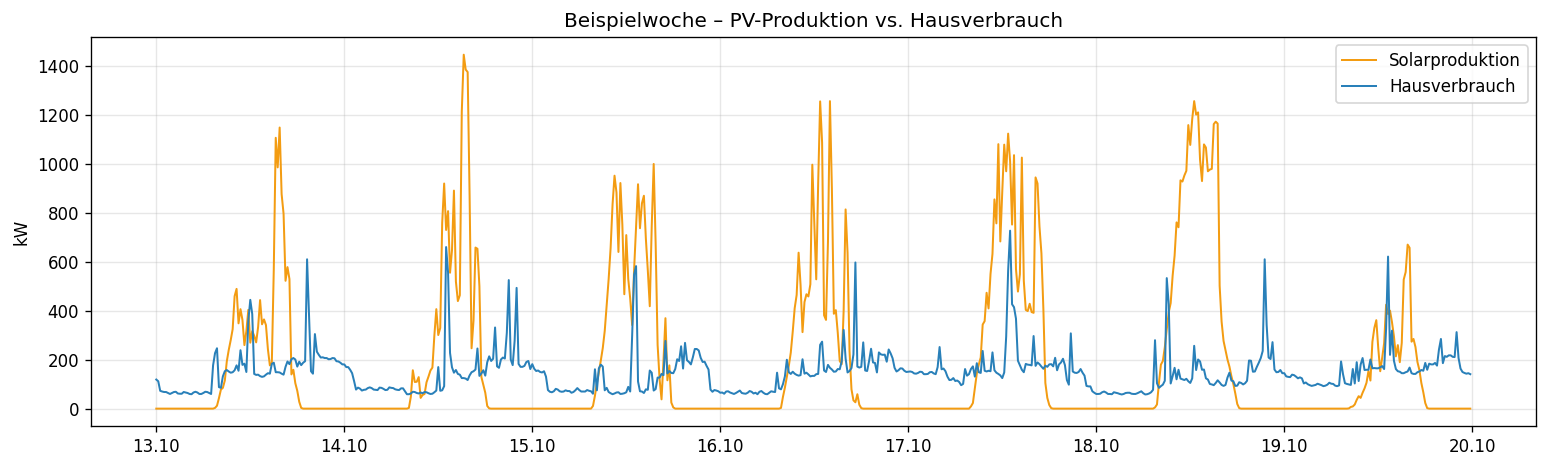

In [14]:
#SetUp
import sys
sys.path.insert(0, '..')

import json
import numpy as np
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from src.data.preprocessing import load_pv_data
from src.data.splitting import time_series_split, split_summary
from src.features.feature_engineering import add_time_features

TARGET_PV   = "Solarproduktion"
TARGET_LOAD = "Hausverbrauch"
RESULTS_DIR = Path("../results/05_grundlast")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3})

#---------------------#

df = load_pv_data()
df = add_time_features(df)

print(f"Zeitraum: {df['timestamp'].min().date()} – {df['timestamp'].max().date()}")
print(f"Datenpunkte: {len(df):,}  (15-min-Auflösung)")

# 7-Tage-Beispiel
start = df["timestamp"].iloc[len(df) // 2].floor("D")
mask  = (df["timestamp"] >= start) & (df["timestamp"] < start + pd.Timedelta(days=7))
sub   = df[mask].set_index("timestamp")

fig, ax = plt.subplots(figsize=(13, 4))

ax.plot(sub.index, sub[TARGET_PV], color="#f39c12", linewidth=1.2, label="Solarproduktion")
ax.plot(sub.index, sub[TARGET_LOAD], color="#2980b9", linewidth=1.2, label="Hausverbrauch")

ax.set_ylabel("kW")
ax.set_title("Beispielwoche – PV-Produktion vs. Hausverbrauch")
ax.legend()

ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
ax.xaxis.set_major_locator(mdates.DayLocator())

plt.tight_layout()
plt.show()

#print("\nHausverbrauch – Übersicht:")
#print(df[TARGET_LOAD].describe().round(2))

## 3) Solarproduktion nach Stunde, Wochentag und Saison

### 3.1.) Nach Stunde und Wochentag

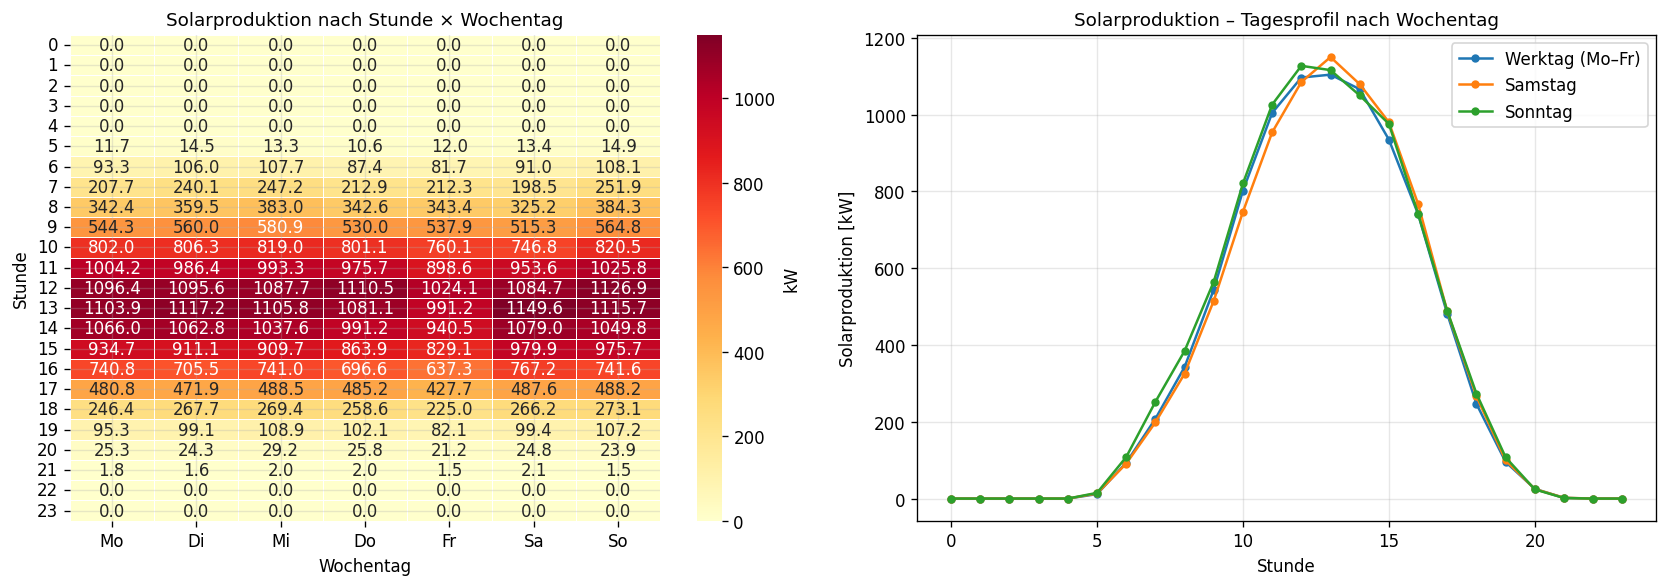

In [15]:
pv_hourly = (
    df.groupby(["day_of_week", "hour"])[TARGET_PV]
    .mean()
    .reset_index(name="solarproduktion")
)

pivot = pv_hourly.pivot(index="hour", columns="day_of_week", values="solarproduktion")
pivot.columns = ["Mo", "Di", "Mi", "Do", "Fr", "Sa", "So"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
sns.heatmap(
    pivot,
    ax=axes[0],
    cmap="YlOrRd",
    annot=True,
    fmt=".1f",
    linewidths=0.4,
    cbar_kws={"label": "kW"},
)

axes[0].set_title("Solarproduktion nach Stunde × Wochentag", fontsize=11)
axes[0].set_xlabel("Wochentag")
axes[0].set_ylabel("Stunde")

# Tagesprofil
for dow, name in [(0, "Werktag (Mo–Fr)"), (5, "Samstag"), (6, "Sonntag")]:
    sub = pv_hourly[pv_hourly["day_of_week"] == dow]
    axes[1].plot(sub["hour"], sub["solarproduktion"], marker="o", markersize=4, label=name)

axes[1].set_title("Solarproduktion – Tagesprofil nach Wochentag", fontsize=11)
axes[1].set_xlabel("Stunde")
axes[1].set_ylabel("Solarproduktion [kW]")
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.2.) Nach Saison


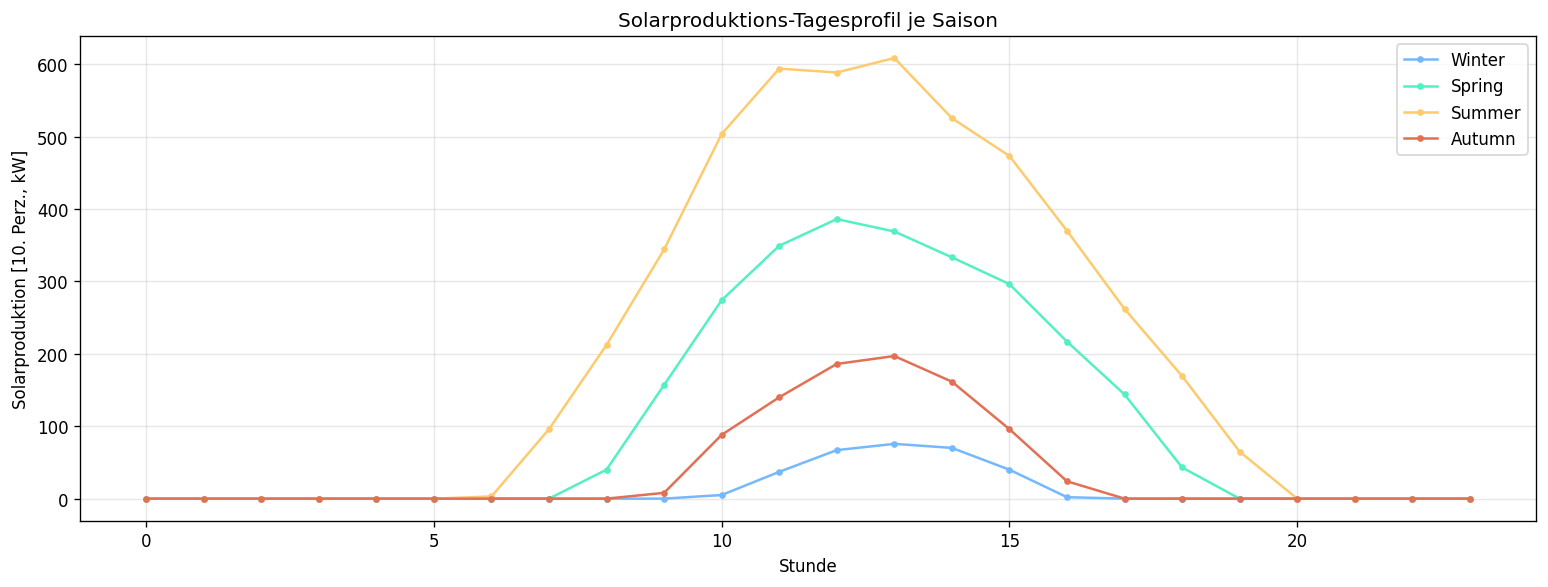

In [25]:
# Grundlast = 10. Perzentil des Hausverbrauchs je Stunde × Wochentag
# → robuster gegenüber Ausreißern als Minimum

PERCENTILE = 10  # anpassbar

# Saison-Mapping
season_map = {
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Autumn", 10: "Autumn", 11: "Autumn"
}

df["season"] = df["timestamp"].dt.month.map(season_map)

season_order = ["Winter", "Spring", "Summer", "Autumn"]
season_colors = {
    "Winter": "#74b9ff",
    "Spring": "#55efc4",
    "Summer": "#fdcb6e",
    "Autumn": "#e17055"
}

fig, ax = plt.subplots(figsize=(13, 5))

# Tagesprofil je Saison
for season in season_order:
    profile = (
        df[df["season"] == season]
        .groupby("hour")[TARGET_PV]
        .quantile(PERCENTILE / 100)
    )
    
    ax.plot(
        profile.index,
        profile.values,
        marker="o",
        markersize=3,
        label=season,
        color=season_colors[season]
    )

ax.set_xlabel("Stunde")
ax.set_ylabel(f"Solarproduktion [{PERCENTILE}. Perz., kW]")
ax.set_title("Solarproduktions-Tagesprofil je Saison")
ax.legend()

plt.tight_layout()
plt.show()

## 4) Gegenüberstellung Solarproduktion vs. Grundlast

### 4.1) Nach Stunde und Wochentag

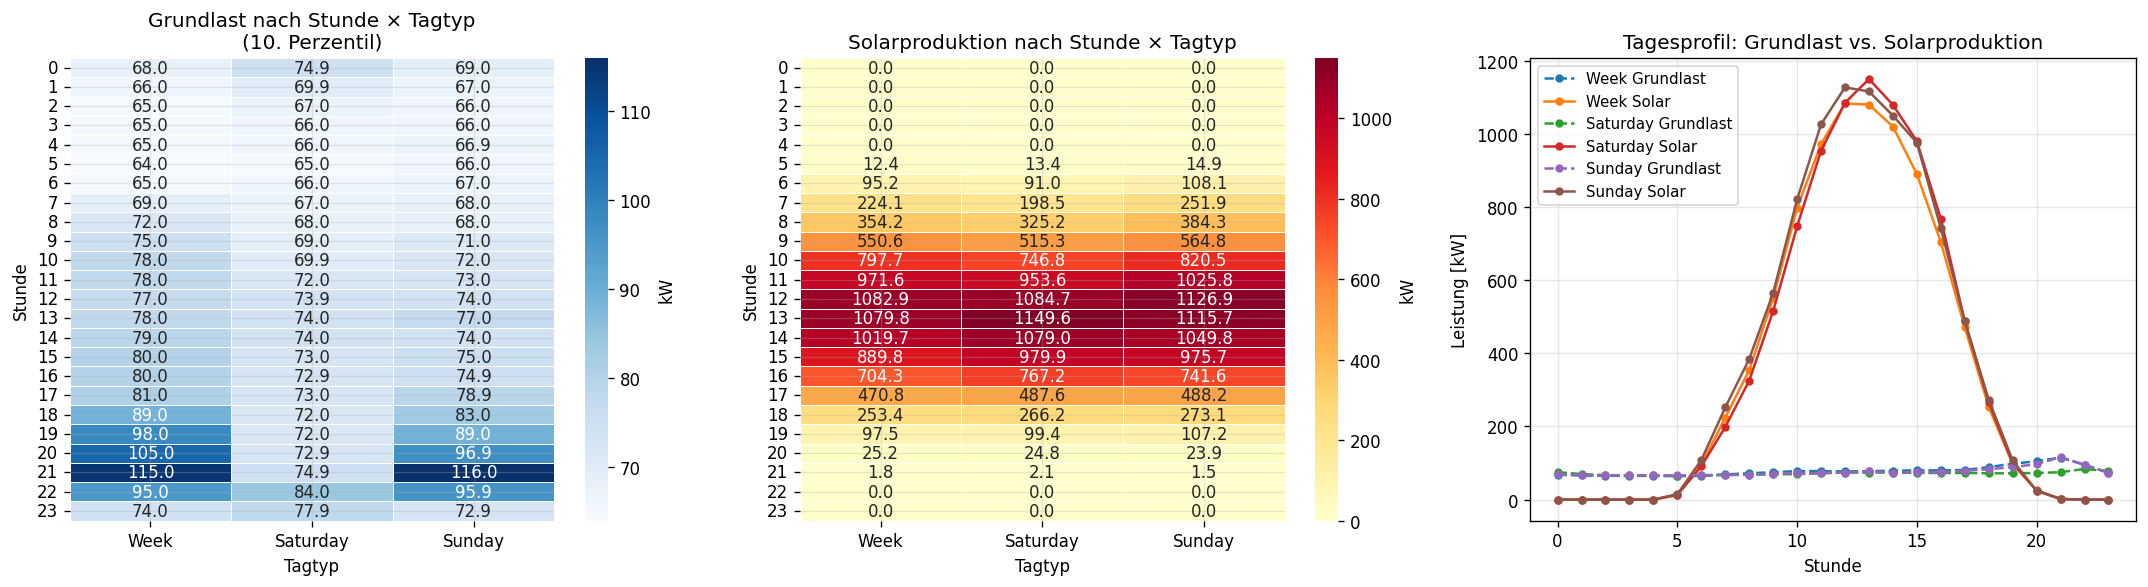

In [ ]:
# Wochentage gruppieren
def day_group(d):
    if d <= 4:
        return "Week"
    elif d == 5:
        return "Saturday"
    else:
        return "Sunday"

df["day_group"] = df["day_of_week"].apply(day_group)

day_order = ["Week", "Saturday", "Sunday"]

# --------------------------------------------------
# Grundlast aggregieren
# --------------------------------------------------
load_hourly = (
    df.groupby(["day_group", "hour"])[TARGET_LOAD]
    .quantile(PERCENTILE / 100)
    .reset_index(name="grundlast")
)

# --------------------------------------------------
# Solarproduktion aggregieren
# --------------------------------------------------
pv_hourly = (
    df.groupby(["day_group", "hour"])[TARGET_PV]
    .mean()
    .reset_index(name="solarproduktion")
)

# --------------------------------------------------
# Pivots für Heatmaps
# --------------------------------------------------
pivot_load = load_hourly.pivot(index="hour", columns="day_group", values="grundlast")
pivot_pv   = pv_hourly.pivot(index="hour", columns="day_group", values="solarproduktion")

pivot_load = pivot_load[day_order]
pivot_pv   = pivot_pv[day_order]

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Grundlast Heatmap
sns.heatmap(
    pivot_load,
    ax=axes[0],
    cmap="Blues",
    annot=True,
    fmt=".1f",
    linewidths=0.4,
    cbar_kws={"label": "kW"},
)
axes[0].set_title(f"Grundlast nach Stunde × Tagtyp\n({PERCENTILE}. Perzentil)")
axes[0].set_xlabel("Tagtyp")
axes[0].set_ylabel("Stunde")

# Solarproduktion Heatmap
sns.heatmap(
    pivot_pv,
    ax=axes[1],
    cmap="YlOrRd",
    annot=True,
    fmt=".1f",
    linewidths=0.4,
    cbar_kws={"label": "kW"},
)
axes[1].set_title("Solarproduktion nach Stunde × Tagtyp")
axes[1].set_xlabel("Tagtyp")
axes[1].set_ylabel("Stunde")

# Vergleich Linienplot
for day in day_order:
    sub_load = load_hourly[load_hourly["day_group"] == day]
    sub_pv   = pv_hourly[pv_hourly["day_group"] == day]

    axes[2].plot(
        sub_load["hour"],
        sub_load["grundlast"],
        linestyle="--",
        marker="o",
        markersize=4,
        label=f"{day} Grundlast"
    )

    axes[2].plot(
        sub_pv["hour"],
        sub_pv["solarproduktion"],
        linestyle="-",
        marker="o",
        markersize=4,
        label=f"{day} Solar"
    )

axes[2].set_title("Tagesprofil: Grundlast vs. Solarproduktion")
axes[2].set_xlabel("Stunde")
axes[2].set_ylabel("Leistung [kW]")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

### 4.2) Nach Saison


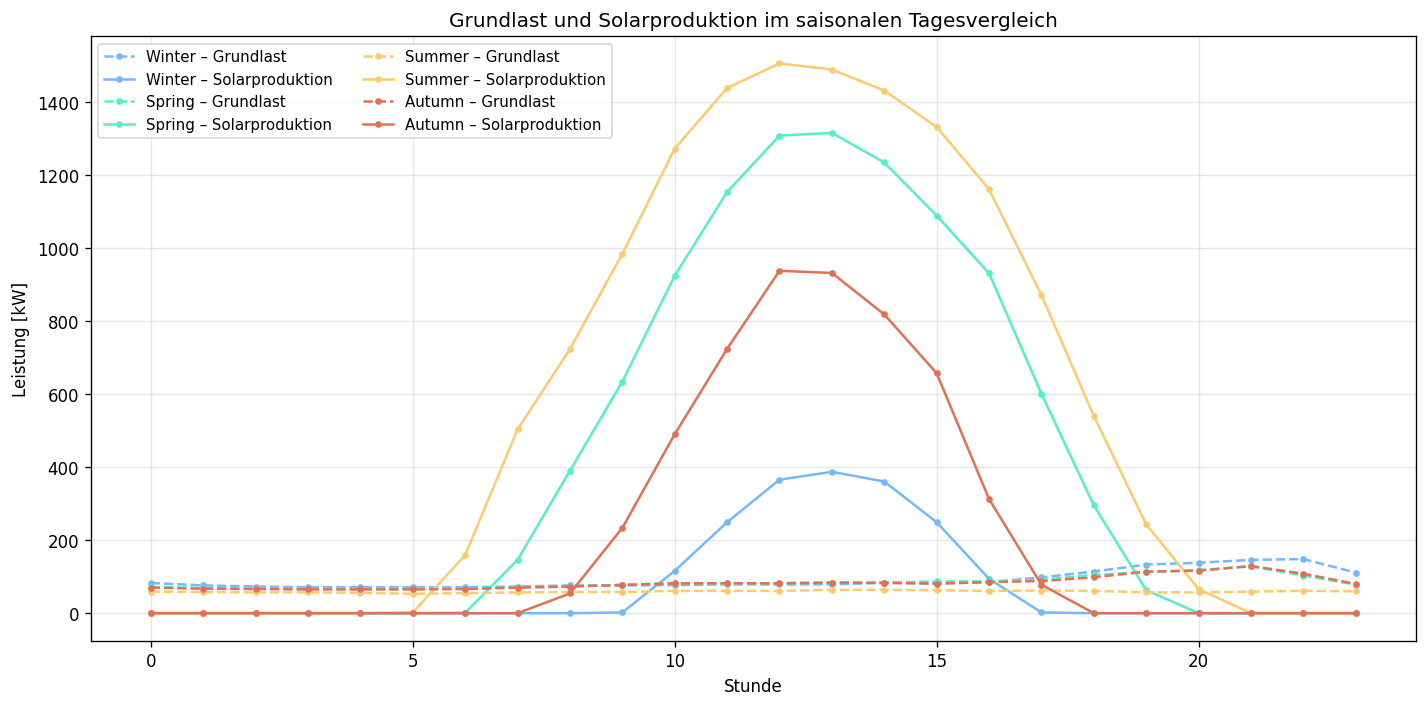

In [19]:
# Kompakte Vergleichsgrafik: Tagesprofile von Grundlast und Solarproduktion je Saison

season_map = {
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Autumn", 10: "Autumn", 11: "Autumn"
}

df["season"] = df["timestamp"].dt.month.map(season_map)

season_order = ["Winter", "Spring", "Summer", "Autumn"]
season_colors = {
    "Winter": "#74b9ff",
    "Spring": "#55efc4",
    "Summer": "#fdcb6e",
    "Autumn": "#e17055"
}

plt.figure(figsize=(12, 6))

for season in season_order:
    profile_load = (
        df[df["season"] == season]
        .groupby("hour")[TARGET_LOAD]
        .quantile(PERCENTILE / 100)
    )
    profile_pv = (
        df[df["season"] == season]
        .groupby("hour")[TARGET_PV]
        .median()
    )

    plt.plot(
        profile_load.index, profile_load.values,
        linestyle="--", marker="o", markersize=3,
        color=season_colors[season], label=f"{season} – Grundlast"
    )
    plt.plot(
        profile_pv.index, profile_pv.values,
        linestyle="-", marker="o", markersize=3,
        color=season_colors[season], label=f"{season} – Solarproduktion"
    )

plt.xlabel("Stunde")
plt.ylabel("Leistung [kW]")
plt.title("Grundlast und Solarproduktion im saisonalen Tagesvergleich")
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()